In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'
TEST_YEAR = '2024'
TEST_MONTH = '6'
NUTS2_EL = 'αττικης'

In [3]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [4]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_{TEST_YEAR}.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(42, 112)


In [5]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL301,2024,1,23.825080,38.055971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.179333,13.241571,18.026946,18.026946,NaN,6.904151,4.908238,8.618559,8.618559,NaN,10.041742,9.074905,13.322753,13.322753,4.53934,18.614557,NaN,0.0,0.0,0.0,557.585678,93.866667,3.027957,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.000000,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0
1,EL302,2024,1,23.686502,38.024894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.957484,13.905429,18.527161,18.527161,NaN,8.005871,6.717429,10.643806,10.643806,NaN,10.981677,10.311429,14.585484,14.585484,4.53934,18.614557,NaN,0.0,0.0,0.0,577.855733,554.000000,17.870968,21.000000,18.500000,42.045455,855.463723,45.0,1.0,44.0,12.000000,17.500000,31.666667,10.000000,572.0,175.0,0.0,122.914545,311.0,4.0,6.0,251.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,33589.0,158798.0,39983.0,232370.0,31767.0,161647.0,52146.0,245560.0,5159.56,1589.0,2120.0,0
2,EL303,2024,1,23.757527,37.973503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.571742,12.777786,18.078129,18.078129,NaN,8.141290,6.215929,9.757226,9.757226,NaN,10.856516,9.496857,13.917677,13.917677,4.53934,18.614557,NaN,0.0,0.0,0.0,484.330368,3595.300000,115.977419,20.458333,17.416667,39.583333,849.453924,44.0,0.0,44.0,11.500000,17.000000,31.333333,10.000000,480.0,174.0,0.0,135.392319,284.0,1.0,13.0,238.0,32,9,30,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.00000,1.621831,58763.0,333312.0,87717.0,479792.0,54658.0,337392.0,128106.0,520156.0,27952.79,4042.0,5750.0,0
3,EL304,2024,1,23.74536

In [6]:
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
len(data_test.NUTS3_ID.unique())

7

In [8]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [9]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL301,2024,6,23.825080,38.055971,0.242947,0.027965,-0.271503,-0.027965,0.248521,0.032022,-0.274399,-0.032022,0.029679,0.022925,0.021960,0.022925,30.893286,11.833484,15.167149,18.239548,26.853778,16.419333,7.042301,8.088161,9.059548,14.650667,23.656310,9.437892,11.627655,13.649548,20.752222,12.658000,35.796667,4.173785,31.600592,34.616848,129.387346,613.701603,5483.133333,176.875269,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.000000,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0,1.224647e-16,-1.0
1,EL302,2024,6,23.686502,38.024894,0.110906,-0.012751,-0.168419,0.012751,0.122412,-0.007154,-0.175599,0.007154,0.026506,0.012664,0.023656,0.012664,32.307571,13.915032,16.596483,19.168194,28.569200,17.900000,7.783935,9.503655,10.866774,16.326000,25.103786,10.849484,13.050069,15.017484,22.447600,14.510000,38.546000,4.447706,29.050005,32.582513,137.878873,641.827228,6755.000000,217.903226,21.000000,18.500000,42.045455,855.463723,45.0,1.0,44.0,12.000000,17.500000,31.666667,10.000000,572.0,175.0,0.0,122.914545,311.0,4.0,6.0,251.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,33589.0,158798.0,39983.0,232370.0,31767.0,161647.0,52146.0,245560.0,5159.56,1589.0,2120.0,0,1.224647e-16,-1.0
2,EL303,2024,6,23.757527,37.973503,0.168578,-0.010847,-0.203709,0.010847,0.162207,0.017368,-0.183925,-0.017368,0.036282,0.018998,0.032453,0.018998,30.912571,12.635161,15.306069,18.595613,27.249400,17.525571,7.748065,9.145862,10.398774,15.664000,24.219071,10.191613,12.225966,14.497194,21.456700,13.196000,37.156000,3.821468,36.010512,38.012280,118.465513,575.483963,7968.000000,257.032258,20.458333,17.416667,39.583333,849.453924,44.0,0.0,44.0,11.500000,17.000000,31.333333,10.000000,480.0,174.0,0.0,135.392319,284.0,1.0,13.0,238.0,32,9,30,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.

In [10]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [11]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [12]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [13]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
4,EL305,2024,6,23.886562,38.040564,0.006365
5,EL306,2024,6,23.395319,38.091064,0.003358
0,EL301,2024,6,23.825080,38.055971,0.003054
2,EL303,2024,6,23.757527,37.973503,0.001950
1,EL302,2024,6,23.686502,38.024894,0.001321


In [14]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [15]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [16]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL30,Aττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [17]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL301,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [18]:
greece_lau1.head()

,NAME,geometry
0,Ελευσίνας,"POLYGON ((23.50387 38.13648, 23.50497 38.13616..."
1,Ιλίου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
2,Ύδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
3,Αίγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
4,Αγίας Βαρβάρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."


In [19]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,MARATHONA RESERVOIR,2982333.8,11410.567,"POLYGON ((23.87974 38.17811, 23.88232 38.17924...",0


In [20]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [21]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [22]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL301,2024,6,23.8251,38.0560,0.003054,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,2024,6,23.6865,38.0249,0.001321,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,2024,6,23.7575,37.9735,0.001950,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,2024,6,23.7454,37.9064,0.001129,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,2024,6,23.8866,38.0406,0.006365,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
5,EL306,2024,6,23.3953,38.0911,0.003358,Δυτική Αττική,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
6,EL307,2024,6,23.2188,37.0018,0.001102,"Πειραιάς, Νήσοι","MULTIPOLYGON (((23.93391 37.47779, 23.94228 37..."


In [23]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

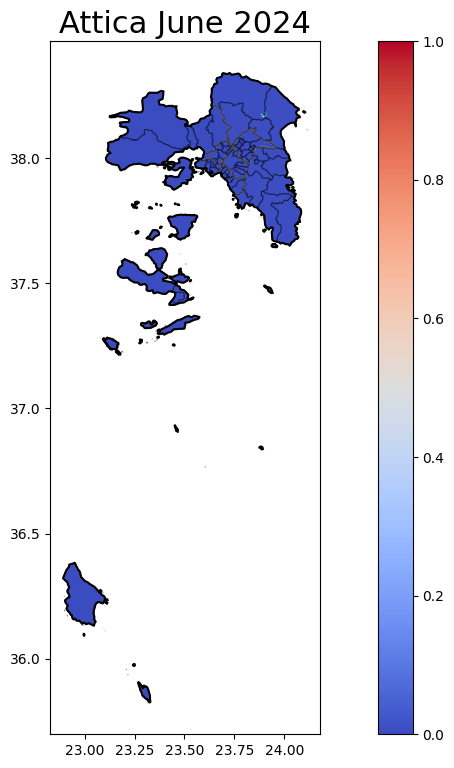

In [24]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [25]:
color_0 = '#5686db'
color_50 = '#f98c37'
color_100 = '#e81015'

# Define the colorscale
colorscale_custom_1 = [
    [0, color_0],
    # [0.25, color_25],
    [0.5, color_50],
    # [0.75, color_75],
    [1, color_100]
]

In [26]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, greece_nuts2_gdf, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=colorscale_custom_1, opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [27]:
color_0 = '#3a4cc0'

color_50 = '#f87e31'

color_100 = '#b40526'

# Define the colorscale
colorscale_custom_2 = [
    [0, color_0],
 
    [0.5, color_50],
 
    [1, color_100]
]

In [28]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, greece_nuts2_gdf, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=colorscale_custom_2, opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [31]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = f'Attica June 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [30]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL301,2024,6,23.8251,38.0560,0.003054,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,2024,6,23.6865,38.0249,0.001321,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,2024,6,23.7575,37.9735,0.001950,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,2024,6,23.7454,37.9064,0.001129,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,2024,6,23.8866,38.0406,0.006365,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
5,EL306,2024,6,23.3953,38.0911,0.003358,Δυτική Αττική,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
6,EL307,2024,6,23.2188,37.0018,0.001102,"Πειραιάς, Νήσοι","MULTIPOLYGON (((23.93391 37.47779, 23.94228 37..."
